## ESA CHANGE - Experiments with data and Random Forest 


In [102]:
# Setup and constants

# Import external packages
import numpy as np
import xarray as xr
from   netCDF4 import Dataset
import matplotlib.pyplot as plt
import pandas as pd
import math
import glob
import seaborn as sns
import sys
import os
from tqdm.auto import tqdm
from dask.diagnostics import ProgressBar

# Import PML packages
# sys.path.append("/users/rsg/anla/code/satellite/match-maker/")
# from match_maker import extract

# Constants
KELVIN_TO_CELSIUS = -273.15



In [ ]:
# Open environmental multi-file datasets

env_file_patt = '/data/datasets/sst/esa-cci-sst/v3.0.1/global/1d/202?/??/??/*SST*.nc'

# Estimate number of files included
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
with ProgressBar():
    env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords')
print ('Done')

# match_maker.extract.gridded.nearest(ds, points, k=1, return_distance=False, units='km')

# Tips for using Xarray for matchups:
# https://gis.stackexchange.com/questions/225100/extract-time-series-values-from-a-3d-lon-lat-time-netcdf-file-using-python


print(f'Variables: {list(env_ds.keys())}')
da = env_ds['analysed_sst'] + KELVIN_TO_CELSIUS
da

# Do we have to invert the array? 

Env dataset contains 2071 files
Opening multi-file env data, this may take several minutes...


/tmp/ipykernel_1376742/1427316432.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords')


Done
Variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'analysed_sst', 'analysed_sst_uncertainty', 'sea_ice_fraction', 'mask']


<xarray.DataArray 'analysed_sst' (time: 2071, lat: 3600, lon: 7200)> Size: 215GB
dask.array<add, shape=(2071, 3600, 7200), dtype=float32, chunksize=(1, 900, 1800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 17kB 2020-01-01T12:00:00 ... 2025-09-01T12...
  * lat      (lat) float32 14kB -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

In [126]:
# Load observed locations from CSV file
obs_data_root = '/data/datasets/Projects/CHANGE/data'
obs_data_name = os.path.join(obs_data_root, 'Surfers_Against_Sewage', 'sas_gastro_all_cases_23feb2026.csv')

obs_df = pd.read_csv(obs_data_name)
# Looks like 'n/a' are correctly turned into 'NaN' for missing data.

# Rename columns
obs_df.rename(columns={'Long':'lon', 'Lat':'lat'}, inplace=True)

# Add time variable, at midday for dates
obs_df['date_time'] = pd.to_datetime(obs_df['dateenteredwater'], dayfirst=True) + pd.Timedelta(hours=12)
obs_df

,Location,lat,lon,Water Company,Classification,dateenteredwater,Gatro,ENT,VIRAL,RESPIRATORY,ear_infection,skin_infection,other,drvisited,drattributedsicknesstowater,daysoffwork,date_time
0,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,19/05/2023,1,0,0,0,0,0,0,0.0,NaN,0.0,2023-05-19 12:00:00
1,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,29/08/2023,1,0,0,0,0,0,0,1.0,1.0,1.0,2023-08-29 12:00:00
2,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,11/12/2023,1,0,0,0,0,0,0,1.0,1.0,0.0,2023-12-11 12:00:00
3,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,11/02/2024,1,0,0,0,0,0,0,0.0,NaN,0.0,2024-02-11 12:00:00
4,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,18/08/2024,1,0,0,0,0,0,0,0.0,NaN,6.0,2024-08-18 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4834,Location Unknown,NaN,NaN,NaN,NaN,29/11/2025,1,0,0,0,0,0,0,0.0,NaN,2.0,2025-11-29 12:00:00
4835,Location Unknown,NaN,NaN,NaN,NaN,22/10/2025,1,0,0,0,0,0,0,0.0,NaN,1.0,2025-10-22 12:00:00
4836,Location Unknown,NaN,NaN,NaN,NaN,18/05/2025,1,1,0,0,0,0,0,0.0,NaN,1.0,2025-05-18 12:00:00
4837,Location Unknown,NaN,NaN,NaN,NaN,14/08/2024,1,0,0,0,0,0,0,0.0,NaN,0.0,2024-08-14 12:00:00


In [ ]:
# Try a match-up with SST data

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['date_time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

# Vectorised extraction
# NB produces a lot of 271.35 (=-2.0 'C?), perhaps many are too far inland (700 missing).
# 271.35 is temperature of Arctic water, I guess at (0,0) if lat/lon are NaN. -54.53K is missing.
print('Extracting matchups from dataset...')
method = 'nearest'
values = da.sel(
    time=times,
    lat=lats,
    lon=lons,
    method=method,
)

# Select then interpolate doesn't work for me (3441 missing?)
# values = (
#     da.sel(time=times, method=method)
#     .interp(lat=lats, lon=lons)
# )

obs_df['sst'] = values
print(f'Missing values: {obs_df['sst'].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

Extracting matchups from dataset...
Missing values: 18.9%
Selected columns:


,Location,lat,lon,Water Company,Classification,dateenteredwater,sst
0,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,19/05/2023,NaN
1,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,29/08/2023,NaN
2,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,11/12/2023,NaN
3,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,11/02/2024,NaN
4,Lowestoft South,52.464922,1.746256263656619,Anglian Water,Good,18/08/2024,NaN
...,...,...,...,...,...,...,...
4834,Location Unknown,NaN,NaN,NaN,NaN,29/11/2025,-1.799988
4835,Location Unknown,NaN,NaN,NaN,NaN,22/10/2025,-1.799988
4836,Location Unknown,NaN,NaN,NaN,NaN,18/05/2025,-1.799988
4837,Location Unknown,NaN,NaN,NaN,NaN,14/08/2024,-1.799988


In [ ]:
#%%script false --no-raise-error

# Uses slice for neighbourhood average, takes ~20 mins
lat_pad = lon_pad = 0.02  # half width of neighbourhood in degrees, so 0.02 gives ~5x5 km.
time_pad = pd.Timedelta(days=2)
results = []

# You can't use nearest in time if also using a slice in coordinates, so loop through each row of observations.
# Then use time and coords slice. But we should not average in time.
# tqdm makes a progress bar according to the rows of points completed.
for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using slice'):
    nhood = da.sel(
        time=slice(row['date_time'] - time_pad, row['date_time'] + time_pad),
        lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
        lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
    )
    results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         da.sel(time=row['date_time'], method=method)
#         .sel(
#             lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
#             lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
#         )
#     )
#     results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# Nope, doesn't work due to problems with not monotonically increasing?
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         da.sel(time=row['date_time'], method=method, tolerance=pd.Timedelta(days=2))
#         .sel(lat=row['lat'], lon=row['lon'], method=method)
#     )
#     results.append(float(nhood.mean()))

obs_df['sst2'] = results

print(f'Missing values: {obs_df['sst2'].isnull().sum().sum() / len(obs_df):.1%}')


Extracting matchups using slice: 100%|██████████| 4826/4826 [20:43<00:00,  3.88it/s] 

Missing values: 47.2%


nan

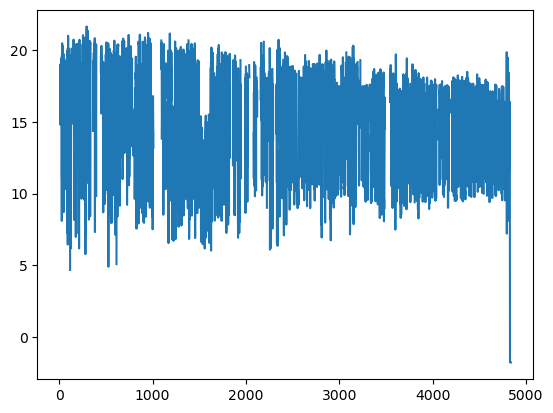

In [150]:
plt.plot(obs_df['sst'])
min(obs_df['sst'])


In [149]:
out_data_name = os.path.join(obs_data_root, 'outputs', 'sas_23feb_test_sst.csv')
obs_df.to_csv(out_data_name)